# Spotify Song Popularity Analysis

To analyze how different audio features are associated with song popularity on Spotify.

Author: Maria Horozova

## Introduction

Music streaming platforms generate large amounts of data describing audio characteristics of songs.

Spotify provides features such as danceability, energy, loudness, acousticness, tempo, and valence, which can be used to analyze patterns related to song popularity.

Two independent Spotify-related datasets were used in this project:
- A large Spotify tracks dataset containing detailed audio features
- A dataset containing Top 50 Spotify songs from 2019

## Objective

The objective of this project is to analyze Spotify music datasets in order to identify relationships between audio characteristics and song popularity.

## Research Questions

- Do popular songs share similar audio characteristics?
- Which audio features are most strongly correlated with popularity?
- Can popularity be predicted using Spotify audio features?

## Hypothesis

It is hypothesized that songs with higher danceability and energy levels are more likely to achieve higher popularity scores.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [5]:
top = pd.read_csv("top50.csv", encoding='latin1')
tracks = pd.read_csv("dataset.csv")

In [6]:
print(top.shape)
print(tracks.shape)

(50, 14)
(114000, 21)


In [7]:
top.head()

,Unnamed: 0,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,1,Señorita,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
1,2,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,3,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85
3,4,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86
4,5,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94


In [8]:
tracks.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [9]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [10]:
top.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        50 non-null     int64 
 1   Track.Name        50 non-null     object
 2   Artist.Name       50 non-null     object
 3   Genre             50 non-null     object
 4   Beats.Per.Minute  50 non-null     int64 
 5   Energy            50 non-null     int64 
 6   Danceability      50 non-null     int64 
 7   Loudness..dB..    50 non-null     int64 
 8   Liveness          50 non-null     int64 
 9   Valence.          50 non-null     int64 
 10  Length.           50 non-null     int64 
 11  Acousticness..    50 non-null     int64 
 12  Speechiness.      50 non-null     int64 
 13  Popularity        50 non-null     int64 
dtypes: int64(11), object(3)
memory usage: 5.6+ KB


In [11]:
tracks.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [12]:
top.isnull().sum()

Unnamed: 0          0
Track.Name          0
Artist.Name         0
Genre               0
Beats.Per.Minute    0
Energy              0
Danceability        0
Loudness..dB..      0
Liveness            0
Valence.            0
Length.             0
Acousticness..      0
Speechiness.        0
Popularity          0
dtype: int64

In [13]:
tracks = tracks.dropna()

In [14]:
tracks.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## Data Cleaning

The datasets were checked for missing values to ensure data consistency and reliability.

The larger Spotify tracks dataset contained only a very small number of missing values. These incomplete rows were removed during preprocessing.

The Top 50 Spotify dataset did not contain missing values.

This cleaning process ensures that the statistical analysis is performed on complete and consistent observations.

In [15]:
tracks.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [16]:
top.describe()

,Unnamed: 0,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
count,50.00000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,120.060000,64.060000,71.38000,-5.660000,14.660000,54.600000,200.960000,22.160000,12.480000,87.500000
std,14.57738,30.898392,14.231913,11.92988,2.056448,11.118306,22.336024,39.143879,18.995553,11.161596,4.491489
min,1.00000,85.000000,32.000000,29.00000,-11.000000,5.000000,10.000000,115.000000,1.000000,3.000000,70.000000
25%,13.25000,96.000000,55.250000,67.00000,-6.750000,8.000000,38.250000,176.750000,8.250000,5.000000,86.000000
50%,25.50000,104.500000,66.500000,73.50000,-6.000000,11.000000,55.500000,198.000000,15.000000,7.000000,88.000000
75%,37.75000,137.500000,74.750000,79.75000,-4.000000,15.750000,69.500000,217.500000,33.750000,15.000000,90.750000
max,50.00000,190.000000,88.000000,90.00000,-2.000000,58.000000,95.000000,309.000000,75.000000,46.000000,95.000000


## Descriptive Statistics Analysis

The descriptive statistics reveal several interesting patterns in the Spotify datasets.

In the larger Spotify tracks dataset, the average popularity is approximately 33, suggesting that most songs achieve moderate popularity levels rather than becoming major hits.

The average danceability score is around 0.57, indicating that many Spotify tracks are moderately danceable. Similarly, the average energy level is relatively high, suggesting that energetic songs are common across the platform.

The Top 50 Spotify songs dataset shows substantially higher popularity values, with an average popularity score of approximately 87. This confirms that the dataset represents highly successful and widely streamed songs.

Additionally, Top 50 songs tend to have higher danceability and energy values compared to the broader Spotify dataset. This suggests that highly popular songs may share certain audio characteristics associated with listener engagement.

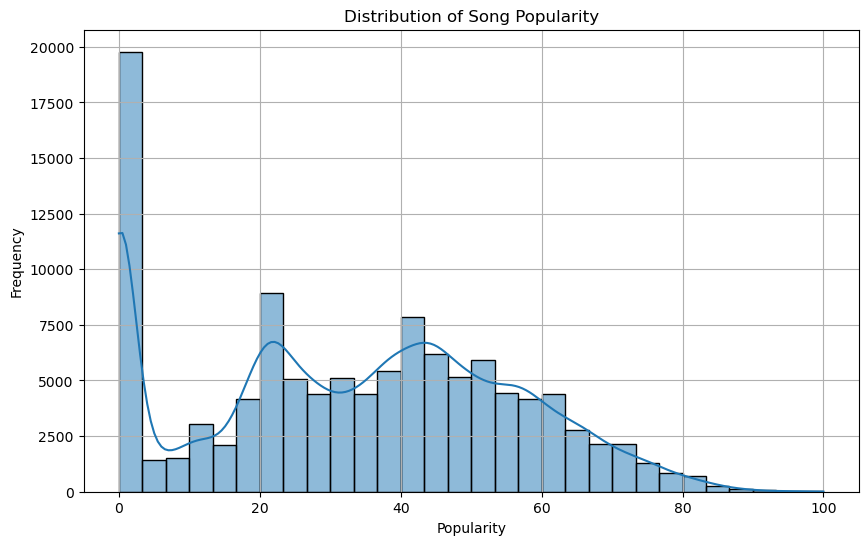

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(tracks['popularity'], bins=30, kde=True)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")

plt.grid()

plt.show()

## Popularity Distribution

The histogram shows the distribution of popularity scores across Spotify tracks.

A large number of songs have low popularity values, while highly popular songs are relatively uncommon.

Most songs are concentrated in the low-to-medium popularity range, indicating that achieving high popularity on Spotify is relatively rare.

The distribution appears right-skewed, with a long tail extending toward higher popularity values.

## Danceability Distribution

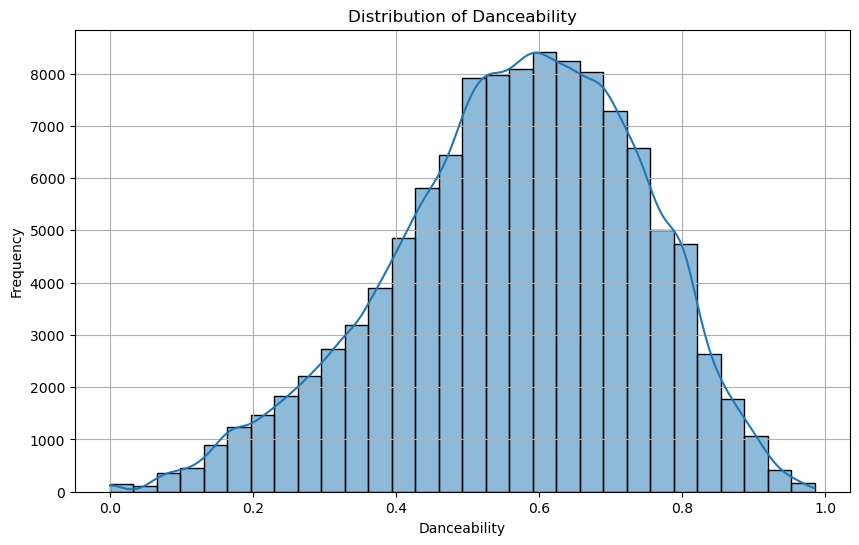

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(tracks['danceability'], bins=30, kde=True)

plt.title("Distribution of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Frequency")

plt.grid()

plt.show()

The histogram shows the distribution of danceability values across Spotify tracks.

Most songs are concentrated in the moderate-to-high danceability range, particularly between 0.5 and 0.7.

The distribution appears approximately bell-shaped, suggesting that extremely low or extremely high danceability values are relatively uncommon.

This indicates that many Spotify tracks share similar rhythmic and dance-oriented characteristics.

# Correlation Analysis

After examining the distributions of individual Spotify audio features, the next step is to analyze how these variables relate to each other.

Correlation analysis measures the strength and direction of linear relationships between variables.

This section focuses on identifying relationships between popularity and Spotify audio characteristics such as:
- Danceability
- Energy
- Loudness
- Acousticness
- Speechiness
- Valence
- Tempo

Understanding these relationships may help identify which musical characteristics are associated with popular songs.

In [21]:
corr_data = tracks[[
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'liveness',
    'valence',
    'tempo'
]]

In [22]:
correlation_matrix = corr_data.corr()

correlation_matrix

,popularity,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo
popularity,1.000000,0.035444,0.001053,0.050420,-0.044930,-0.025458,-0.005397,-0.040522,0.013212
danceability,0.035444,1.000000,0.134325,0.259076,0.108625,-0.171531,-0.131620,0.477347,-0.050448
energy,0.001053,0.134325,1.000000,0.761690,0.142508,-0.733908,0.184795,0.258937,0.247852
loudness,0.050420,0.259076,0.761690,1.000000,0.060826,-0.589804,0.076897,0.279851,0.212447
speechiness,-0.044930,0.108625,0.142508,0.060826,1.000000,-0.002184,0.205218,0.036637,0.017274
acousticness,-0.025458,-0.171531,-0.733908,-0.589804,-0.002184,1.000000,-0.020693,-0.107081,-0.208231
liveness,-0.005397,-0.131620,0.184795,0.076897,0.205218,-0.020693,1.000000,0.019093,0.000603
valence,-0.040522,0.477347,0.258937,0.279851,0.036637,-0.107081,0.019093,1.000000,0.078269
tempo,0.013212,-0.050448,0.247852,0.212447,0.017274,-0.208231,0.000603,0.078269,1.000000


## Correlation Interpretation

Correlation values range from -1 to 1.

- Positive values indicate that variables tend to increase together
- Negative values indicate inverse relationships
- Values close to zero indicate weak or no linear relationship

This analysis helps identify which audio features are most strongly associated with popularity.

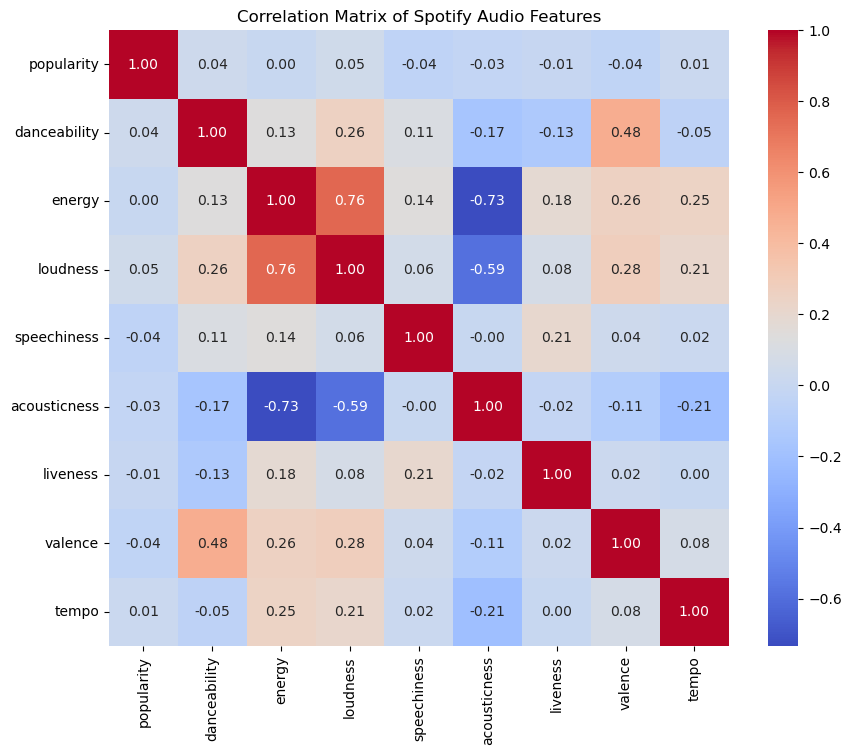

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix of Spotify Audio Features")

plt.show()

## Correlation Matrix Analysis

The correlation matrix visualizes relationships between Spotify audio features and popularity.

Several moderate relationships can be observed between audio characteristics. For example, energy and loudness show a positive correlation, suggesting that energetic songs also tend to be louder.

Acousticness generally shows negative relationships with energetic features, indicating that acoustic tracks often differ from highly energetic songs.

Popularity appears to have relatively weak-to-moderate correlations with individual audio features, suggesting that song popularity is influenced by multiple factors rather than a single characteristic.

## Energy and Popularity

This section examines the relationship between song energy and popularity.

Energy describes the intensity and activity level of a track. Highly energetic songs are typically louder, faster, and more dynamic.

The goal is to determine whether more energetic songs tend to achieve higher popularity on Spotify.

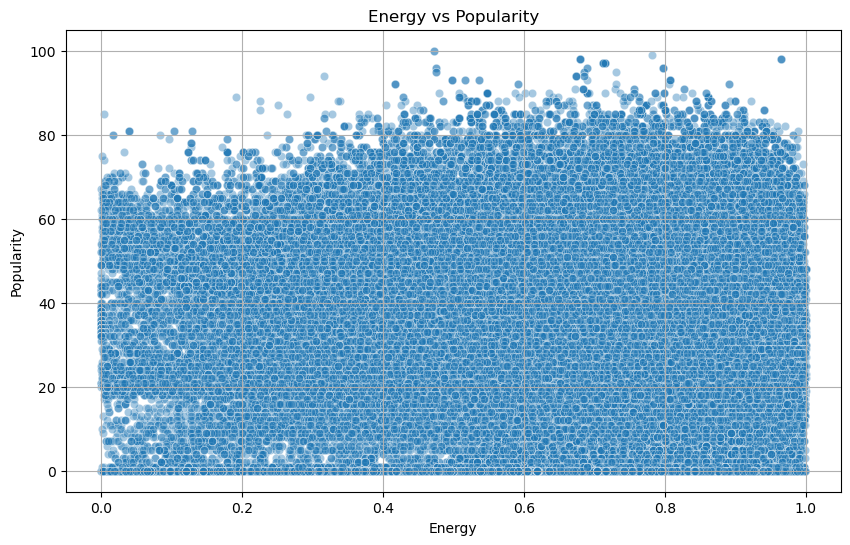

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='energy',
    y='popularity',
    data=tracks,
    alpha=0.4
)

plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")

plt.grid()

plt.show()

## Energy vs Popularity Analysis

The scatterplot illustrates the relationship between song energy and popularity.

Each point represents an individual Spotify track.

The data shows a wide spread of popularity values across all energy levels, suggesting that energy alone does not strongly determine popularity.

However, songs with medium-to-high energy levels appear to contain a larger concentration of highly popular tracks, indicating a possible weak positive relationship.

Overall, the relationship between energy and popularity appears relatively weak, suggesting that popularity is likely influenced by multiple factors rather than energy alone.

## Danceability and Popularity

This section examines the relationship between danceability and song popularity.

Danceability measures how suitable a track is for dancing based on rhythm, beat stability, and tempo.

The analysis explores whether highly danceable songs tend to achieve greater popularity on Spotify.

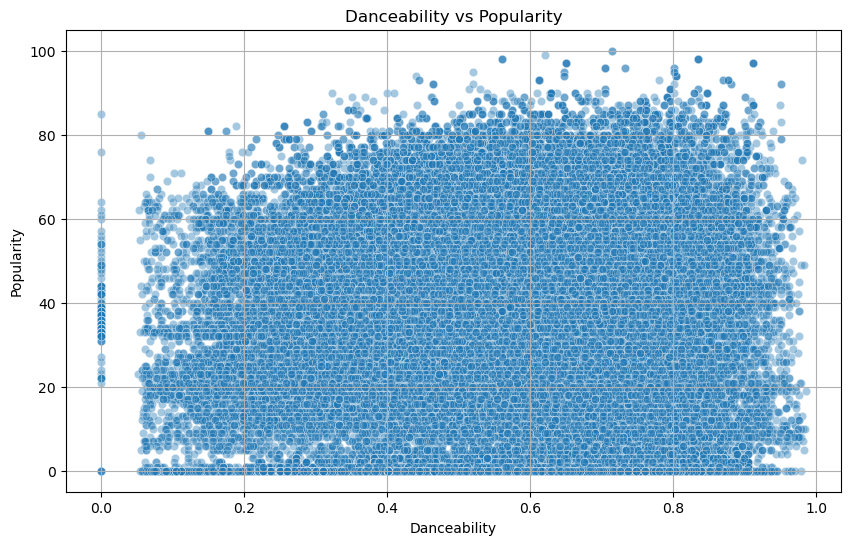

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='danceability',
    y='popularity',
    data=tracks,
    alpha=0.4
)

plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")

plt.grid()

plt.show()

## Danceability vs Popularity Analysis

The scatterplot illustrates the relationship between danceability and popularity.

Songs with very low danceability values appear less likely to achieve extremely high popularity scores.

A larger concentration of highly popular songs can be observed in the moderate-to-high danceability range, particularly between 0.5 and 0.8.

Compared to energy, danceability appears to show a somewhat stronger relationship with popularity. However, the wide spread of popularity values across all danceability levels suggests that popularity is influenced by multiple factors rather than danceability alone.

## Genre Analysis

This section examines how popularity varies across different music genres.

Genre analysis helps identify whether certain genres tend to achieve higher average popularity levels on Spotify.

The analysis focuses on comparing average popularity scores between genres and identifying the most successful genres in the dataset.

In [28]:
genre_popularity = tracks.groupby('track_genre')['popularity'].mean()

In [29]:
top_genres = genre_popularity.sort_values(ascending=False)

top_genres.head(10)

track_genre
pop-film     59.283000
k-pop        56.952953
chill        53.651000
sad          52.379000
grunge       49.594000
indian       49.539000
anime        48.772000
emo          48.128000
sertanejo    47.866000
pop          47.576000
Name: popularity, dtype: float64

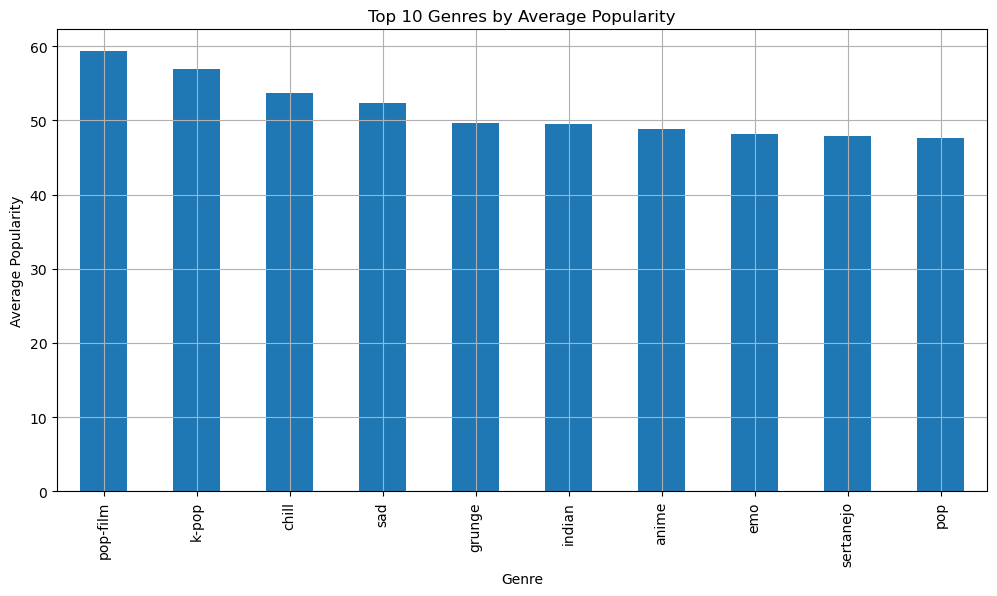

In [30]:
plt.figure(figsize=(12,6))

top_genres.head(10).plot(kind='bar')

plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")

plt.grid()

plt.show()

## Genre Popularity Analysis

The grouped analysis reveals notable differences in average popularity between music genres.

Genres such as pop-film, k-pop, and pop show some of the highest average popularity values in the dataset.

These results suggest that mainstream and globally popular genres tend to achieve higher streaming popularity on Spotify.

Additionally, genres such as chill and sad music also demonstrate relatively high popularity, possibly reflecting listener preferences for emotional and relaxing music.

## Multiple Linear Regression

Multiple linear regression is used to examine how several Spotify audio features jointly relate to song popularity.

Unlike simple pairwise comparisons, multiple regression evaluates the combined influence of multiple variables simultaneously.

The model uses the following predictors:
- Danceability
- Energy
- Loudness
- Valence
- Tempo

The target variable is song popularity.

In [32]:
X = tracks[[
    'danceability',
    'energy',
    'loudness',
    'valence',
    'tempo'
]]

y = tracks['popularity']

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,danceability,7.160280
1,energy,-6.682667
2,loudness,0.497742
3,valence,-6.912882
4,tempo,0.012757


In [35]:
r_squared = model.score(X, y)

print("R-squared:", r_squared)

R-squared: 0.011036500927931958


## Regression Results

The regression model produced several interesting results regarding the relationship between Spotify audio features and popularity.

Danceability shows a positive coefficient, suggesting that more danceable songs tend to achieve higher popularity levels.

Loudness also demonstrates a small positive relationship with popularity.

In contrast, energy and valence show negative coefficients within the multivariable model, indicating that highly energetic or highly positive songs are not necessarily more popular after controlling for other variables.

Tempo appears to have only a very small effect on popularity.

The model achieved an R-squared value of approximately 0.011, meaning that the selected audio features explain only a small portion of the variation in popularity.

This suggests that Spotify popularity is influenced by many additional factors beyond audio characteristics alone, including artist recognition, marketing, streaming algorithms, and listener trends.

## Residual Analysis

Residual analysis helps evaluate how well the regression model fits the data.

Residuals represent the differences between the actual popularity values and the popularity values predicted by the regression model.

Analyzing residuals helps identify patterns, unexplained variation, and potential limitations of the model.

In [36]:
predictions = model.predict(X)

residuals = y - predictions

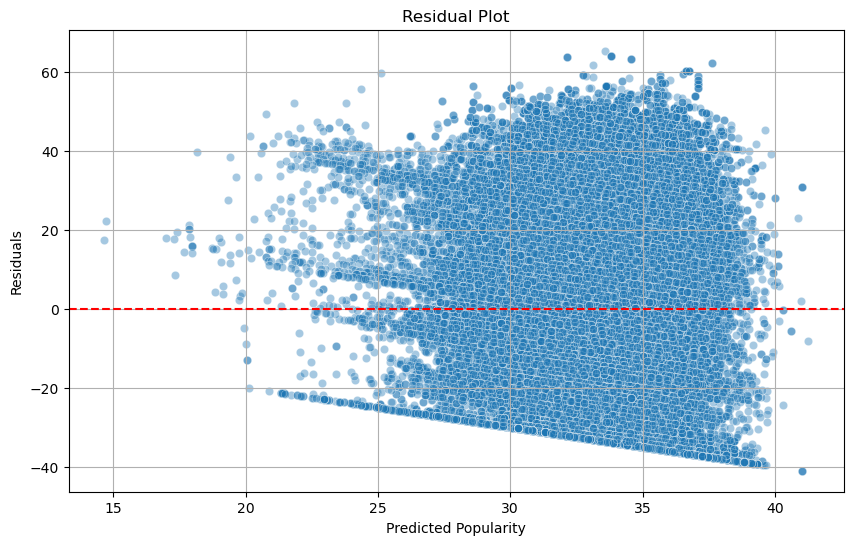

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=predictions,
    y=residuals,
    alpha=0.4
)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Popularity")
plt.ylabel("Residuals")

plt.grid()

plt.show()

## Residual Analysis Interpretation

The residual plot illustrates the differences between actual popularity values and the popularity values predicted by the regression model.

The residuals show a wide spread around zero, indicating that the model does not fully explain the variation in Spotify popularity.

This suggests that popularity is influenced by many additional factors beyond the selected audio features, including artist recognition, marketing, recommendation algorithms, and social trends.

No strong systematic pattern is clearly visible in the residuals, suggesting that the model captures some general relationships, although its predictive power remains relatively limited.

## Comparison Between General Spotify Tracks and Top Songs

This section compares the general Spotify tracks dataset with the Top 50 Spotify songs dataset.

The goal is to examine whether highly popular songs differ from average Spotify tracks in terms of:
- Danceability
- Energy
- Loudness
- Popularity

This comparison helps identify characteristics that may distinguish top-charting songs from the broader Spotify population.

In [41]:
top['Danceability'] = top['Danceability'] / 100

top['Energy'] = top['Energy'] / 100

In [42]:
comparison = pd.DataFrame({
    'General Tracks': [
        tracks['danceability'].mean(),
        tracks['energy'].mean(),
        tracks['loudness'].mean(),
        tracks['popularity'].mean()
    ],
    
    'Top 50 Songs': [
        top['Danceability'].mean(),
        top['Energy'].mean(),
        top['Loudness..dB..'].mean(),
        top['Popularity'].mean()
    ]
},

index=[
    'Danceability',
    'Energy',
    'Loudness',
    'Popularity'
])

comparison

,General Tracks,Top 50 Songs
Danceability,0.566801,0.7138
Energy,0.641383,0.6406
Loudness,-8.258950,-5.6600
Popularity,33.238827,87.5000


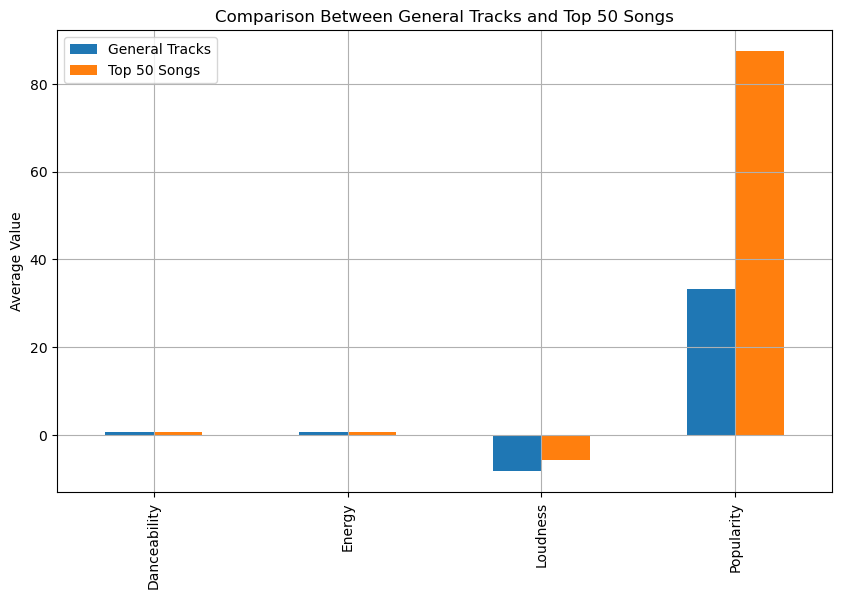

In [43]:
comparison.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Comparison Between General Tracks and Top 50 Songs")

plt.ylabel("Average Value")

plt.grid()

plt.show()

## Comparative Analysis

The comparison between the general Spotify tracks dataset and the Top 50 songs dataset reveals several notable differences.

Top 50 songs demonstrate substantially higher danceability values compared to general Spotify tracks, suggesting that highly danceable songs may perform better on streaming platforms.

Energy levels appear relatively similar between the two datasets, indicating that energy alone may not strongly distinguish top-charting songs.

Additionally, Top 50 songs tend to be louder on average and, expectedly, show significantly higher popularity values.

## Genre Danceability Analysis

This section examines which music genres have the highest average danceability values.

The analysis helps identify genres that are generally more rhythm-oriented and suitable for dancing.

Comparing genres may reveal broader musical patterns within Spotify streaming data.

In [48]:
genre_danceability = tracks.groupby('track_genre')[
    'danceability'
].mean()

In [49]:
top_dance_genres = genre_danceability.sort_values(
    ascending=False
)

top_dance_genres.head(10)

track_genre
kids              0.778906
chicago-house     0.766176
reggaeton         0.758521
latino            0.757057
reggae            0.745331
hip-hop           0.736154
dancehall         0.734169
minimal-techno    0.729395
detroit-techno    0.722568
latin             0.721902
Name: danceability, dtype: float64

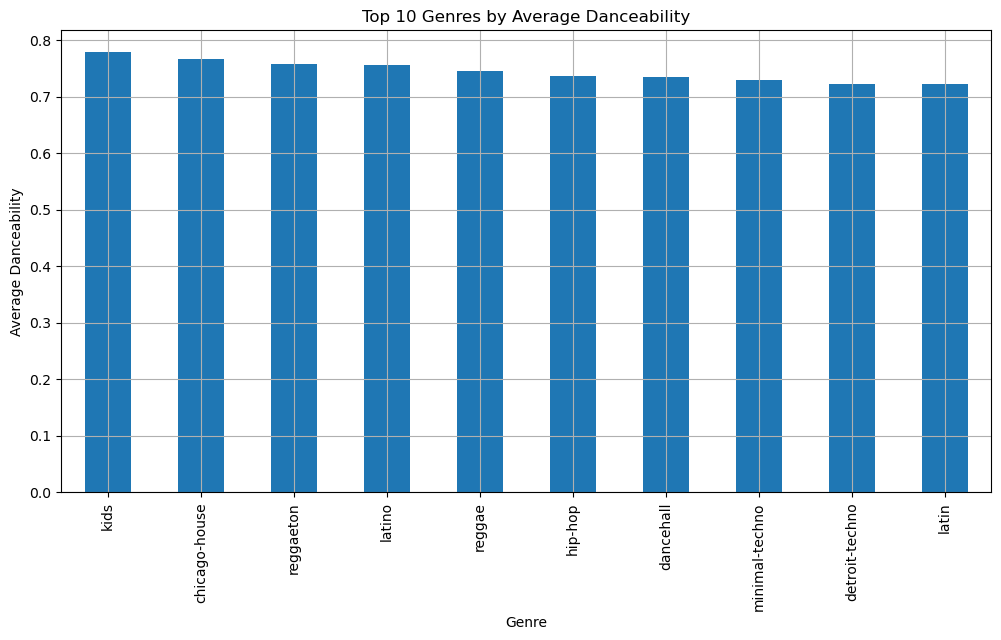

In [50]:
plt.figure(figsize=(12,6))

top_dance_genres.head(10).plot(kind='bar')

plt.title("Top 10 Genres by Average Danceability")

plt.xlabel("Genre")
plt.ylabel("Average Danceability")

plt.grid()

plt.show()

## Genre Danceability Analysis

The grouped analysis reveals significant differences in danceability across music genres.

Genres such as reggaeton, latino, reggae, hip-hop, and house-related genres demonstrate some of the highest average danceability values in the dataset.

These genres are generally characterized by strong rhythmic structures, repetitive beats, and dance-oriented musical patterns.

The results suggest that rhythm-focused genres tend to achieve consistently high danceability scores within Spotify's audio feature system.

## Pairplot Analysis

A pairplot allows simultaneous visualization of relationships between multiple numerical variables.

This type of visualization combines:
- Scatterplots between variable pairs
- Individual variable distributions

The pairplot helps identify broader patterns, trends, clusters, and potential relationships within the Spotify dataset.

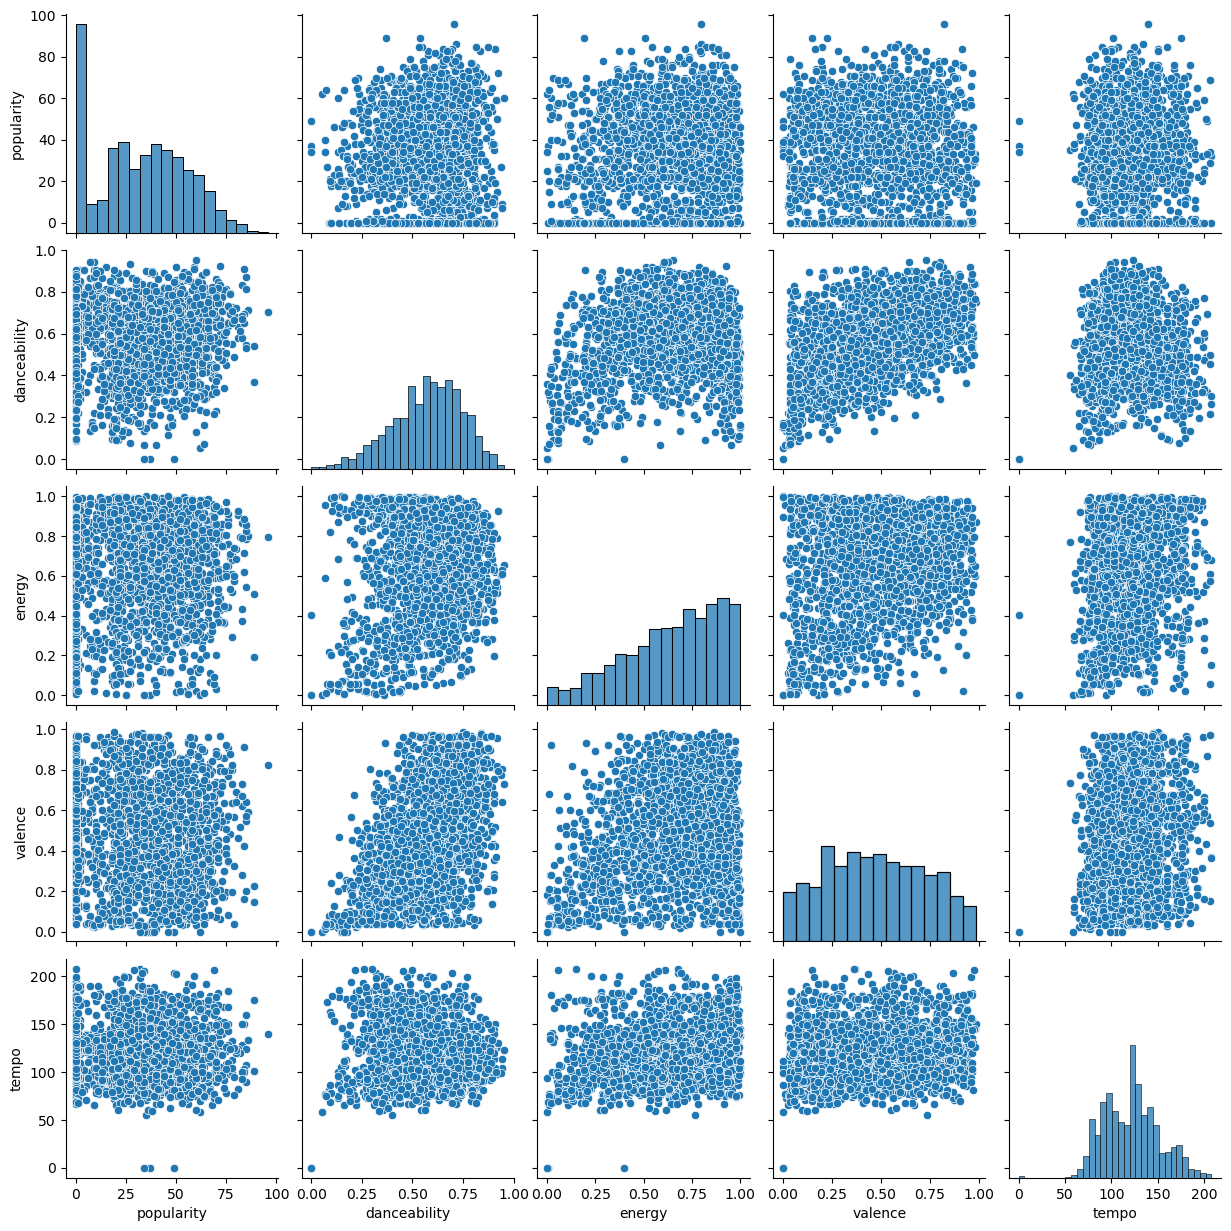

In [52]:
pairplot_data = tracks[[
    'popularity',
    'danceability',
    'energy',
    'valence',
    'tempo'
]].sample(2000)

sns.pairplot(pairplot_data)

plt.show()

## Pairplot Interpretation

The pairplot provides an overview of relationships between several Spotify audio features and popularity.

Most variable relationships appear relatively weak to moderate, supporting earlier findings from the correlation and regression analysis.

Danceability and energy appear to demonstrate some positive association with popularity, although the relationships are not strong enough to fully explain popularity differences.

The visualizations also reveal substantial variability within the dataset, suggesting that Spotify popularity is influenced by many interacting factors.